## **Section 1: Importing Data for Use** ##

In [104]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


## **Section 2: Load and Explore Data** ##

In [105]:
## Load CSV With Pandas and print head ##
df = pd.read_csv('ai_job_market.csv')
print(df.head())

   job_id              company_name    industry                 job_title  \
0       1           Foster and Sons  Healthcare              Data Analyst   
1       2   Boyd, Myers and Ramirez        Tech  Computer Vision Engineer   
2       3                  King Inc        Tech          Quant Researcher   
3       4  Cooper, Archer and Lynch        Tech        AI Product Manager   
4       5                  Hall LLC     Finance            Data Scientist   

                                     skills_required experience_level  \
0  NumPy, Reinforcement Learning, PyTorch, Scikit...              Mid   
1                    Scikit-learn, CUDA, SQL, Pandas           Senior   
2          MLflow, FastAPI, Azure, PyTorch, SQL, GCP            Entry   
3       Scikit-learn, C++, Pandas, LangChain, AWS, R              Mid   
4                    Excel, Keras, SQL, Hugging Face           Senior   

  employment_type               location salary_range_usd posted_date  \
0       Full-time        

In [106]:
## Show values and data types ##
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_id            2000 non-null   int64 
 1   company_name      2000 non-null   object
 2   industry          2000 non-null   object
 3   job_title         2000 non-null   object
 4   skills_required   2000 non-null   object
 5   experience_level  2000 non-null   object
 6   employment_type   2000 non-null   object
 7   location          2000 non-null   object
 8   salary_range_usd  2000 non-null   object
 9   posted_date       2000 non-null   object
 10  company_size      2000 non-null   object
 11  tools_preferred   2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB
None
job_id              0
company_name        0
industry            0
job_title           0
skills_required     0
experience_level    0
employment_type     0
location            0
salary_range_us

In [107]:
## explore categorical data ##
# Focus on key categorical columns for analysis
categorical_columns = ["experience_level", "location", "employment_type", "industry"]

for col in categorical_columns:
    print(f"\n{'='*50}")
    print(f"Value counts for: {col}")
    print(f"{'='*50}")
    print(df[col].value_counts())
    print(f"\nUnique values: {df[col].nunique()}")



Value counts for: experience_level
experience_level
Entry     702
Mid       668
Senior    630
Name: count, dtype: int64

Unique values: 3

Value counts for: location
location
Tracybury, AR             1
Lake Scott, CU            1
East Paige, CM            1
Perezview, FI             1
North Desireeland, NE     1
                         ..
Washingtonmouth, SD       1
Joshuafort, ZA            1
West Brittanyburgh, CG    1
Anthonyshire, OM          1
Benjaminview, NE          1
Name: count, Length: 2000, dtype: int64

Unique values: 2000

Value counts for: employment_type
employment_type
Internship    574
Full-time     509
Contract      465
Remote        452
Name: count, dtype: int64

Unique values: 4

Value counts for: industry
industry
Automotive    300
Education     294
Retail        293
E-commerce    291
Finance       279
Tech          274
Healthcare    269
Name: count, dtype: int64

Unique values: 7


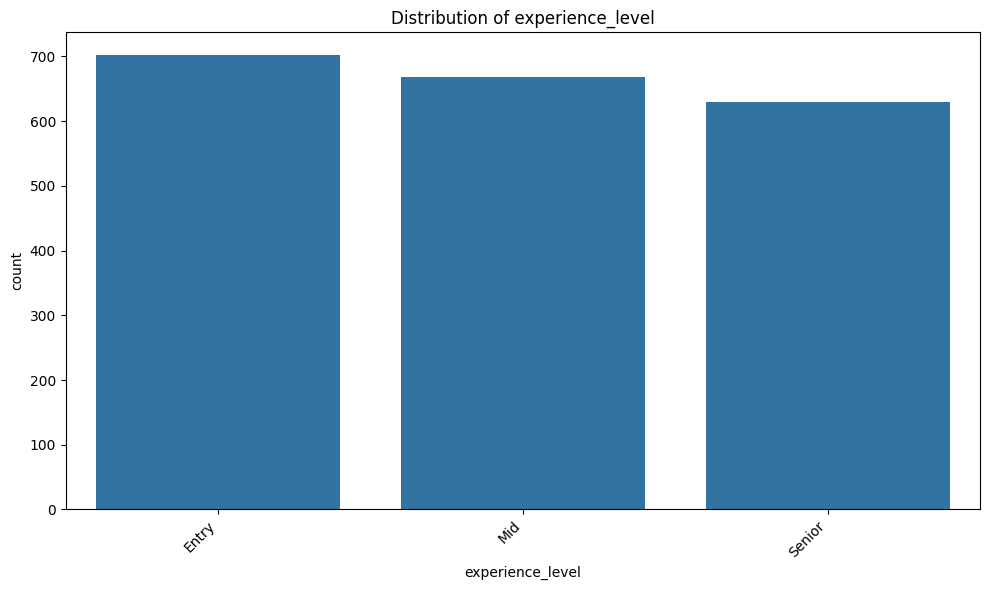

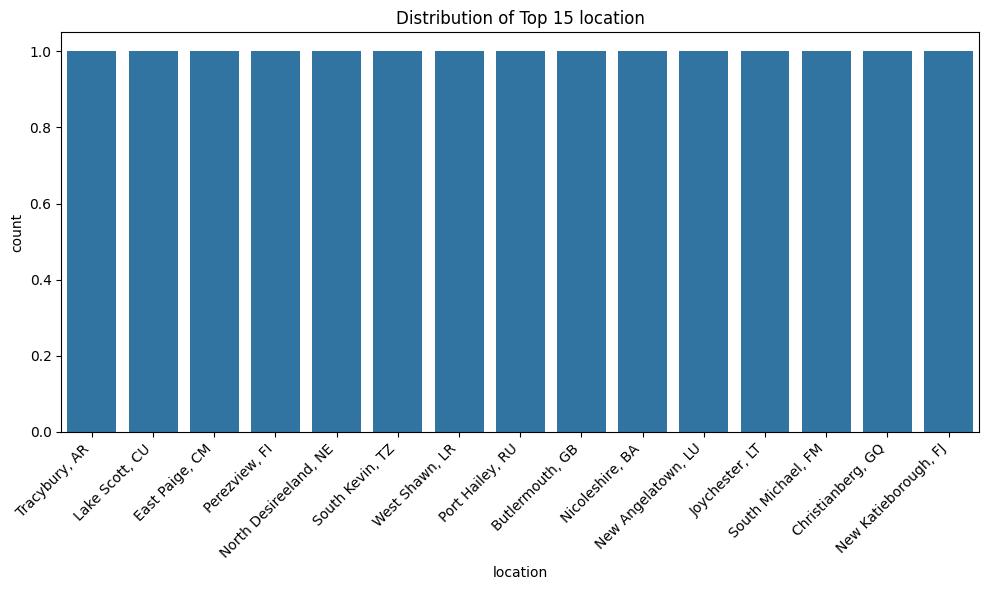

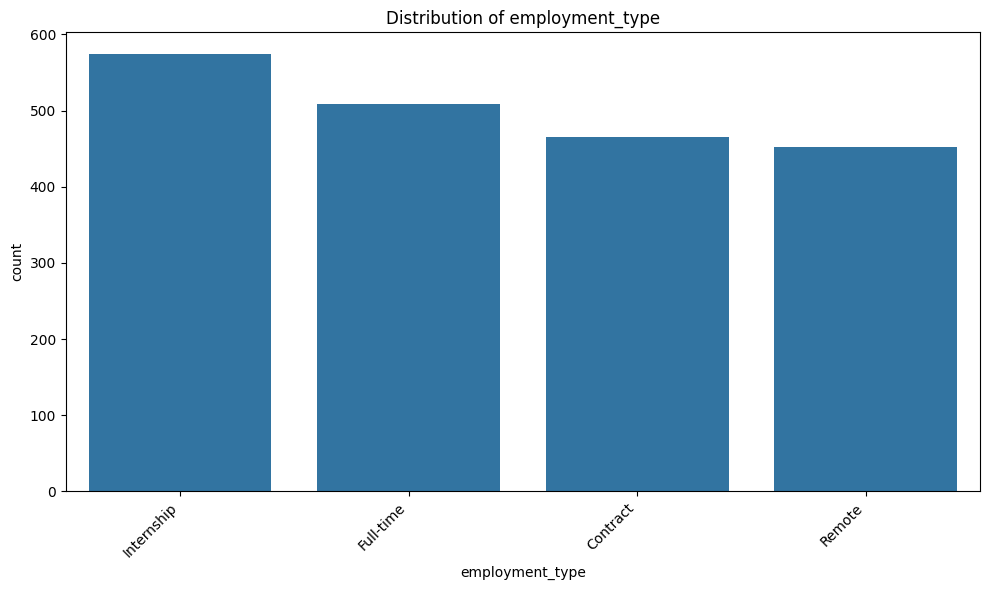

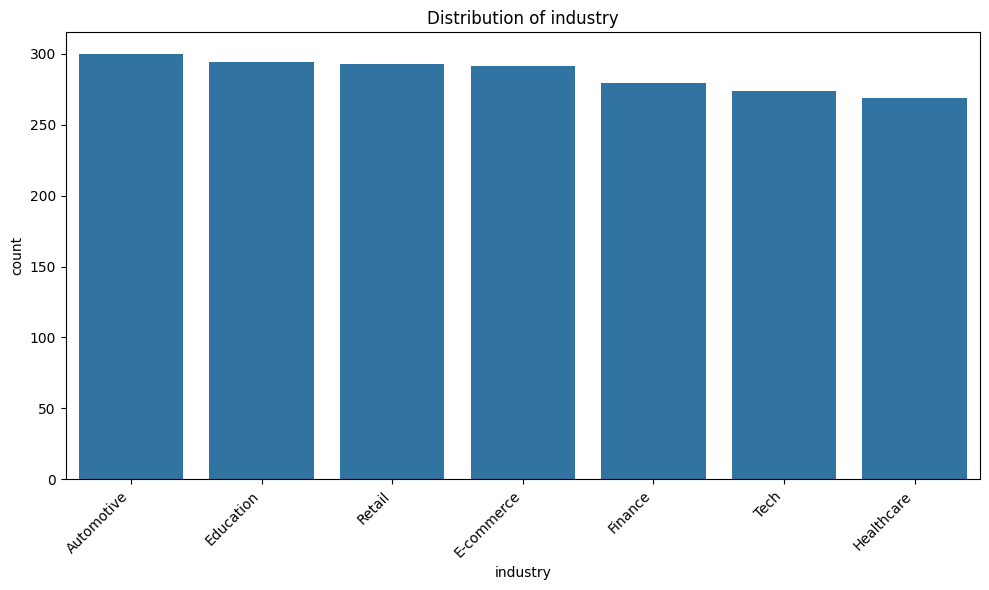

In [108]:
## Explore categorical columns ##
for col in categorical_columns:
    plt.figure(figsize=(10, 6))
    
    # For location, show only top 15 to avoid clutter
    if col == 'location':
        top_locations = df[col].value_counts().head(15)
        sns.countplot(data=df[df[col].isin(top_locations.index)], 
                        x=col, 
                        order=top_locations.index)
        plt.title(f'Distribution of Top 15 {col}')
    else:
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f'Distribution of {col}')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## **Section 3: Data Cleaning** ##

In [109]:
## Handle missing values ##
df = df.dropna()
print("\nData after handling missing values:")
print(df.info())


Data after handling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_id            2000 non-null   int64 
 1   company_name      2000 non-null   object
 2   industry          2000 non-null   object
 3   job_title         2000 non-null   object
 4   skills_required   2000 non-null   object
 5   experience_level  2000 non-null   object
 6   employment_type   2000 non-null   object
 7   location          2000 non-null   object
 8   salary_range_usd  2000 non-null   object
 9   posted_date       2000 non-null   object
 10  company_size      2000 non-null   object
 11  tools_preferred   2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB
None


In [110]:
## Filter for entry-level positions ##
entry_level_df = df[df['experience_level'] == 'Entry']
print(f"\nNumber of entry-level positions: {len(entry_level_df)}")

# calculate percentage of entry-level positions
entry_level_percentage = (len(entry_level_df) / len(df)) * 100
print(f"Percentage of entry-level positions: {entry_level_percentage:.2f}%")


Number of entry-level positions: 702
Percentage of entry-level positions: 35.10%


In [111]:
# Convert dates and extract time features ##
df['posted_date'] = pd.to_datetime(df['posted_date'])
df['posted_year'] = df['posted_date'].dt.year
df['posted_month'] = df['posted_date'].dt.month
df['quarter'] = df['posted_date'].dt.quarter
df['day_of_year'] = df['posted_date'].dt.dayofyear
print("\nData with date features:")
print(df[['posted_date', 'posted_year', 'posted_month', 'quarter', 'day_of_year']].head())


Data with date features:
  posted_date  posted_year  posted_month  quarter  day_of_year
0  2025-08-20         2025             8        3          232
1  2024-03-22         2024             3        1           82
2  2025-09-18         2025             9        3          261
3  2024-05-08         2024             5        2          129
4  2025-02-24         2025             2        1           55


### **Section 4: Feature Engineering** ##

In [112]:
## Create your target variable ##
df['is_entry_level'] = (df['experience_level'].astype(str).str.strip().str.lower() == 'entry').astype(int)

entry_level_df = (
	df[df['is_entry_level'] == 1]
	.groupby(['posted_year', 'posted_month'])
	.size()
	.reset_index(name='job_count')
)

entry_level_df = entry_level_df.sort_values(['posted_year', 'posted_month']).reset_index(drop=True)
entry_level_df['Time_Index'] = entry_level_df.index

print(entry_level_df.head())

   posted_year  posted_month  job_count  Time_Index
0         2023             9         14           0
1         2023            10         31           1
2         2023            11         24           2
3         2023            12         24           3
4         2024             1         35           4


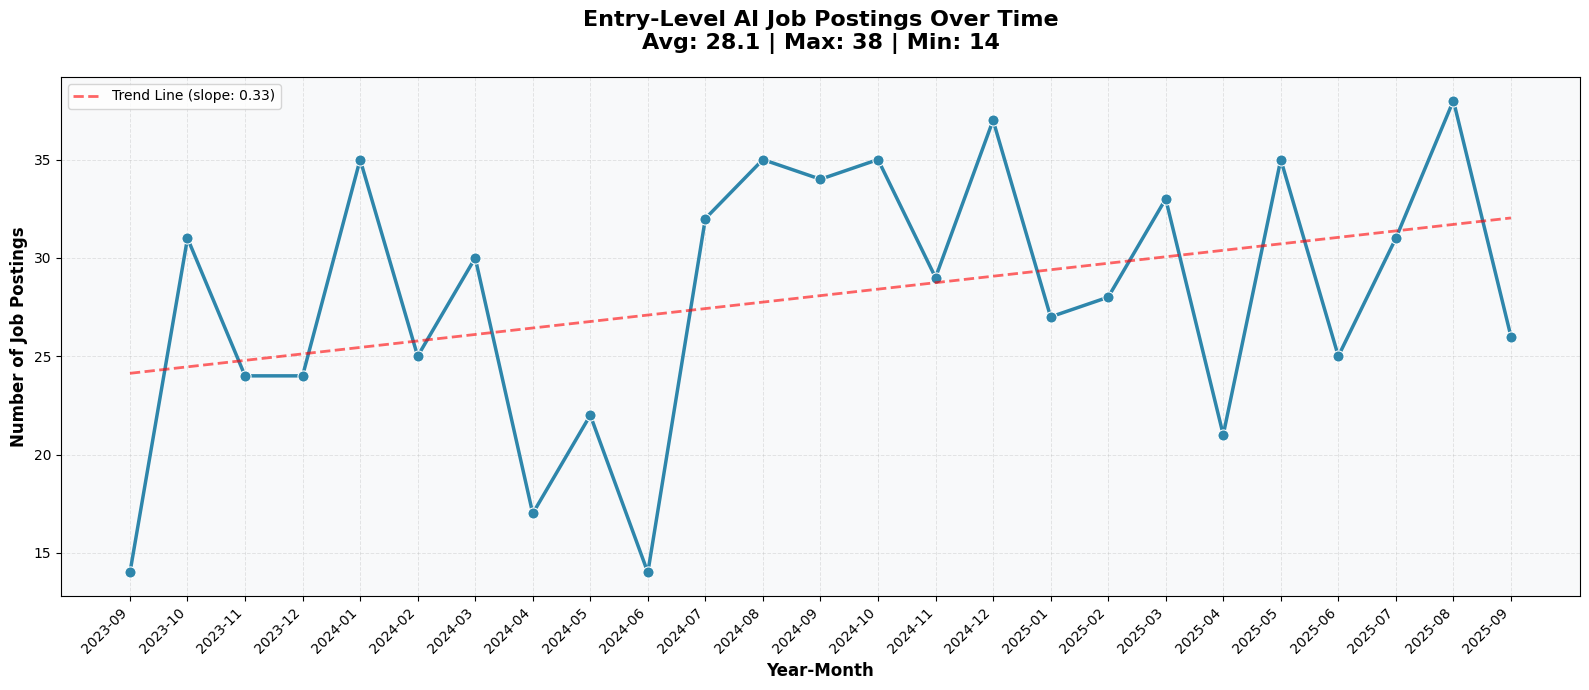


Summary Statistics:
Average monthly postings: 28.08
Maximum postings: 38 (2025-08)
Minimum postings: 14 (2023-09)
Trend: Increasing (0.33 jobs/month)
Time period: 2023-09 to 2025-09
Total months analyzed: 25


In [113]:
## Visualize the job trend over time ##
## - Plot job counts to see if there's growth, seasonality, or patterns
## - This helps you understand what you're trying to predict 

# Create a proper date label combining year and month
entry_level_df['Year_Month'] = entry_level_df['posted_year'].astype(str) + '-' + entry_level_df['posted_month'].astype(str).str.zfill(2)

plt.figure(figsize=(16, 7))

# Create the line plot with enhanced styling
sns.lineplot(data=entry_level_df, x='Time_Index', y='job_count', 
             marker='o', markersize=8, linewidth=2.5, color='#2E86AB')

# Add labels and title with statistics
avg_jobs = entry_level_df['job_count'].mean()
max_jobs = entry_level_df['job_count'].max()
min_jobs = entry_level_df['job_count'].min()

plt.title(f'Entry-Level AI Job Postings Over Time\nAvg: {avg_jobs:.1f} | Max: {max_jobs} | Min: {min_jobs}', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year-Month', fontsize=12, fontweight='bold')
plt.ylabel('Number of Job Postings', fontsize=12, fontweight='bold')

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)

# Replace x-axis tick labels with actual year-month
# Show every nth label to avoid crowding
n = max(1, len(entry_level_df) // 15)  # Show about 15 labels max
tick_positions = range(0, len(entry_level_df), n)
tick_labels = [entry_level_df.iloc[i]['Year_Month'] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Add a subtle background color
ax = plt.gca()
ax.set_facecolor('#F8F9FA')

# Add a trend line
z = np.polyfit(entry_level_df['Time_Index'], entry_level_df['job_count'], 1)
p = np.poly1d(z)
plt.plot(entry_level_df['Time_Index'], p(entry_level_df['Time_Index']), 
         "r--", alpha=0.6, linewidth=2, label=f'Trend Line (slope: {z[0]:.2f})')

plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

# Print summary statistics with year-month info
print(f"\n{'='*50}")
print("Summary Statistics:")
print(f"{'='*50}")
print(f"Average monthly postings: {avg_jobs:.2f}")

max_idx = entry_level_df[entry_level_df['job_count']==max_jobs].index[0]
min_idx = entry_level_df[entry_level_df['job_count']==min_jobs].index[0]

print(f"Maximum postings: {max_jobs} ({entry_level_df.iloc[max_idx]['Year_Month']})")
print(f"Minimum postings: {min_jobs} ({entry_level_df.iloc[min_idx]['Year_Month']})")
print(f"Trend: {'Increasing' if z[0] > 0 else 'Decreasing'} ({z[0]:.2f} jobs/month)")
print(f"Time period: {entry_level_df.iloc[0]['Year_Month']} to {entry_level_df.iloc[-1]['Year_Month']}")
print(f"Total months analyzed: {len(entry_level_df)}")


In [114]:
## Create lag features ##
entry_level_df['lag_1'] = entry_level_df['job_count'].shift(1)
entry_level_df['lag_2'] = entry_level_df['job_count'].shift(2)
entry_level_df['lag_3'] = entry_level_df['job_count'].shift(3)
entry_level_df = entry_level_df.dropna().reset_index(drop=True)
print(entry_level_df.head())

   posted_year  posted_month  job_count  Time_Index Year_Month  lag_1  lag_2  \
0         2023            12         24           3    2023-12   24.0   31.0   
1         2024             1         35           4    2024-01   24.0   24.0   
2         2024             2         25           5    2024-02   35.0   24.0   
3         2024             3         30           6    2024-03   25.0   35.0   
4         2024             4         17           7    2024-04   30.0   25.0   

   lag_3  
0   14.0  
1   31.0  
2   24.0  
3   24.0  
4   35.0  


In [115]:
## Add seasonal features ##
entry_level_df['month_sin'] = np.sin(2 * np.pi * entry_level_df['posted_month'] / 12)
entry_level_df['month_cos'] = np.cos(2 * np.pi * entry_level_df['posted_month'] / 12)
print(entry_level_df.head())

   posted_year  posted_month  job_count  Time_Index Year_Month  lag_1  lag_2  \
0         2023            12         24           3    2023-12   24.0   31.0   
1         2024             1         35           4    2024-01   24.0   24.0   
2         2024             2         25           5    2024-02   35.0   24.0   
3         2024             3         30           6    2024-03   25.0   35.0   
4         2024             4         17           7    2024-04   30.0   25.0   

   lag_3     month_sin     month_cos  
0   14.0 -2.449294e-16  1.000000e+00  
1   31.0  5.000000e-01  8.660254e-01  
2   24.0  8.660254e-01  5.000000e-01  
3   24.0  1.000000e+00  6.123234e-17  
4   35.0  8.660254e-01 -5.000000e-01  


## **Section 5: Train/Test Split** ##

In [116]:
## Split data chronologically ##

# Define features and target
feature_cols = ['lag_1', 'lag_2', 'lag_3', 'month_sin', 'month_cos']
X = entry_level_df[feature_cols]
y = entry_level_df['job_count']

# Chronological split: 80% train, 20% test
split_index = int(len(entry_level_df) * 0.8)
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

# Print detailed split information
print(f"{'='*70}")
print("Train/Test Split Summary")
print(f"{'='*70}")
print(f"\nTotal dataset size: {len(entry_level_df)} months")
print(f"Training set size: {len(X_train)} months ({len(X_train)/len(entry_level_df)*100:.1f}%)")
print(f"Testing set size: {len(X_test)} months ({len(X_test)/len(entry_level_df)*100:.1f}%)")
print(f"\nTraining period: {entry_level_df.iloc[0]['Year_Month']} to {entry_level_df.iloc[split_index-1]['Year_Month']}")
print(f"Testing period: {entry_level_df.iloc[split_index]['Year_Month']} to {entry_level_df.iloc[-1]['Year_Month']}")
print(f"\nNOTE: Dataset is small ({len(entry_level_df)} samples). Consider gathering more data for better predictions.")
print(f"{'='*70}")


Train/Test Split Summary

Total dataset size: 22 months
Training set size: 17 months (77.3%)
Testing set size: 5 months (22.7%)

Training period: 2023-12 to 2025-04
Testing period: 2025-05 to 2025-09

NOTE: Dataset is small (22 samples). Consider gathering more data for better predictions.


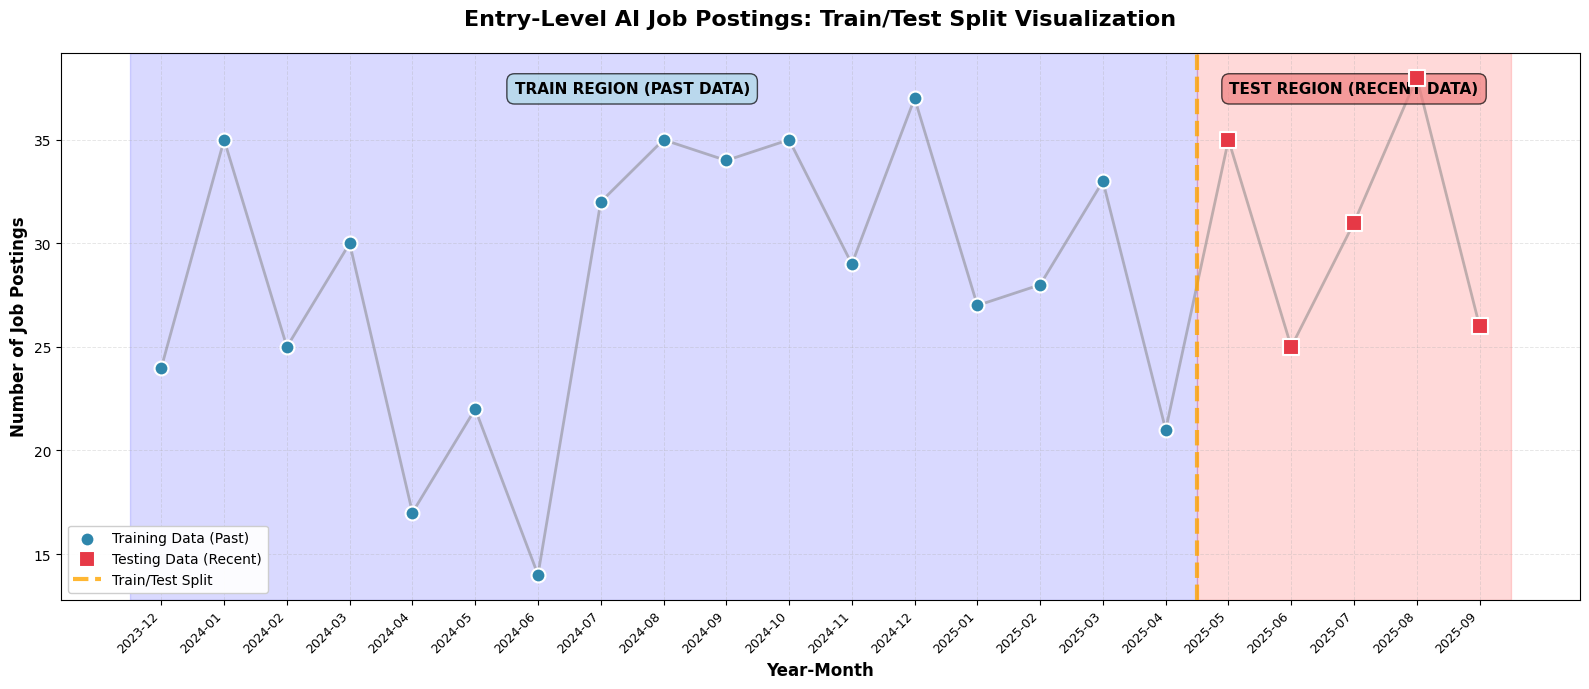


Features being used for prediction:
  • lag_1
  • lag_2
  • lag_3
  • month_sin
  • month_cos

Target variable: job_count (number of entry-level AI job postings)

How the split works:
TRAIN on PAST data (blue points): 2023-12 to 2025-04
  --> The model learns patterns from historical data

TEST on RECENT data (red points): 2025-05 to 2025-09
  --> Evaluate if the model can predict more recent months

This simulates real-world forecasting:
  --> You train on old data, then predict what happens next


In [117]:
## Visualize the split ##
plt.figure(figsize=(16, 7))

# Use sequential indices for x-axis (not Time_Index which may be offset)
x_positions = list(range(len(entry_level_df)))

# Add shaded regions first (so they're in the background)
plt.axvspan(-0.5, split_index-0.5, alpha=0.15, color='blue', zorder=1)
plt.axvspan(split_index-0.5, len(entry_level_df)-0.5, alpha=0.15, color='red', zorder=1)

# Plot the continuous line for all data
plt.plot(x_positions, entry_level_df['job_count'], 
            linewidth=2, color='gray', alpha=0.5, zorder=2)

# Overlay training data points in blue
train_x = x_positions[:split_index]
train_y = entry_level_df.iloc[:split_index]['job_count']
plt.scatter(train_x, train_y, 
            s=100, marker='o', color='#2E86AB', edgecolor='white', 
            linewidth=1.5, label='Training Data (Past)', zorder=4)

# Overlay testing data points in red
test_x = x_positions[split_index:]
test_y = entry_level_df.iloc[split_index:]['job_count']
plt.scatter(test_x, test_y, 
            s=120, marker='s', color='#E63946', edgecolor='white', 
            linewidth=1.5, label='Testing Data (Recent)', zorder=4)

# Add a vertical line at the split
plt.axvline(x=split_index-0.5, color='orange', linestyle='--', 
            linewidth=3, label='Train/Test Split', alpha=0.8, zorder=3)

plt.title('Entry-Level AI Job Postings: Train/Test Split Visualization', 
            fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year-Month', fontsize=12, fontweight='bold')
plt.ylabel('Number of Job Postings', fontsize=12, fontweight='bold')

# Show ALL year-month labels on x-axis for complete clarity
all_tick_labels = [entry_level_df.iloc[i]['Year_Month'] for i in x_positions]
plt.xticks(x_positions, all_tick_labels, rotation=45, ha='right', fontsize=9)

# Add text annotations for regions
plt.text(split_index/2 - 1, plt.ylim()[1]*0.95, 'TRAIN REGION (PAST DATA)', 
            fontsize=11, fontweight='bold', ha='center', 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7))
plt.text(split_index + (len(entry_level_df) - split_index)/2 - 0.5, plt.ylim()[1]*0.95, 
            'TEST REGION (RECENT DATA)', 
            fontsize=11, fontweight='bold', ha='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.7))

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7, zorder=1)
plt.legend(loc='lower left', fontsize=10, framealpha=0.95)
plt.tight_layout()
plt.show()

# Display the actual data being used with clearer explanation
print(f"\n{'='*70}")
print("Features being used for prediction:")
print(f"{'='*70}")
for col in feature_cols:
    print(f"  • {col}")
print(f"\nTarget variable: job_count (number of entry-level AI job postings)")
print(f"\n{'='*70}")
print("How the split works:")
print(f"{'='*70}")
train_start = entry_level_df.iloc[0]['Year_Month']
train_end = entry_level_df.iloc[split_index-1]['Year_Month']
test_start = entry_level_df.iloc[split_index]['Year_Month']
test_end = entry_level_df.iloc[-1]['Year_Month']
print(f"TRAIN on PAST data (blue points): {train_start} to {train_end}")
print("  --> The model learns patterns from historical data")
print(f"\nTEST on RECENT data (red points): {test_start} to {test_end}")
print("  --> Evaluate if the model can predict more recent months")
print(f"\nThis simulates real-world forecasting:")
print("  --> You train on old data, then predict what happens next")
print(f"{'='*70}")

## **Section 6: Baseline Model** ##

In [118]:
## Create baseline predictions ##

# Define MAPE (Mean Absolute Percentage Error) function
def calculate_MAPE(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Calculate training data mean
train_mean = y_train.mean()

# Predict the same value (training mean) for all test months
y_pred_baseline = np.full(y_test.shape, train_mean)

print(f"{'='*70}")
print("BASELINE MODEL: Predicting Training Mean for All Test Months")
print(f"{'='*70}")
print(f"\nTraining data mean: {train_mean:.2f} jobs/month")
print(f"Strategy: Predict {train_mean:.2f} for every test month")
print(f"\nThis simple model serves as a benchmark.")
print(f"Any sophisticated model should perform better than this!")
print(f"{'='*70}")


BASELINE MODEL: Predicting Training Mean for All Test Months

Training data mean: 28.12 jobs/month
Strategy: Predict 28.12 for every test month

This simple model serves as a benchmark.
Any sophisticated model should perform better than this!



BASELINE MODEL PERFORMANCE
Root Mean Squared Error (RMSE): 5.79 jobs
Mean Absolute Error (MAE):      4.98 jobs
Mean Absolute Percentage Error: 15.12%

Interpretation:
  • On average, predictions are off by 4.98 jobs
  • This represents a 15.12% error rate

Detailed Predictions:
  Year_Month  Actual  Baseline_Prediction     Error  Abs_Error
0    2025-05      35            28.117647  6.882353   6.882353
1    2025-06      25            28.117647 -3.117647   3.117647
2    2025-07      31            28.117647  2.882353   2.882353
3    2025-08      38            28.117647  9.882353   9.882353
4    2025-09      26            28.117647 -2.117647   2.117647


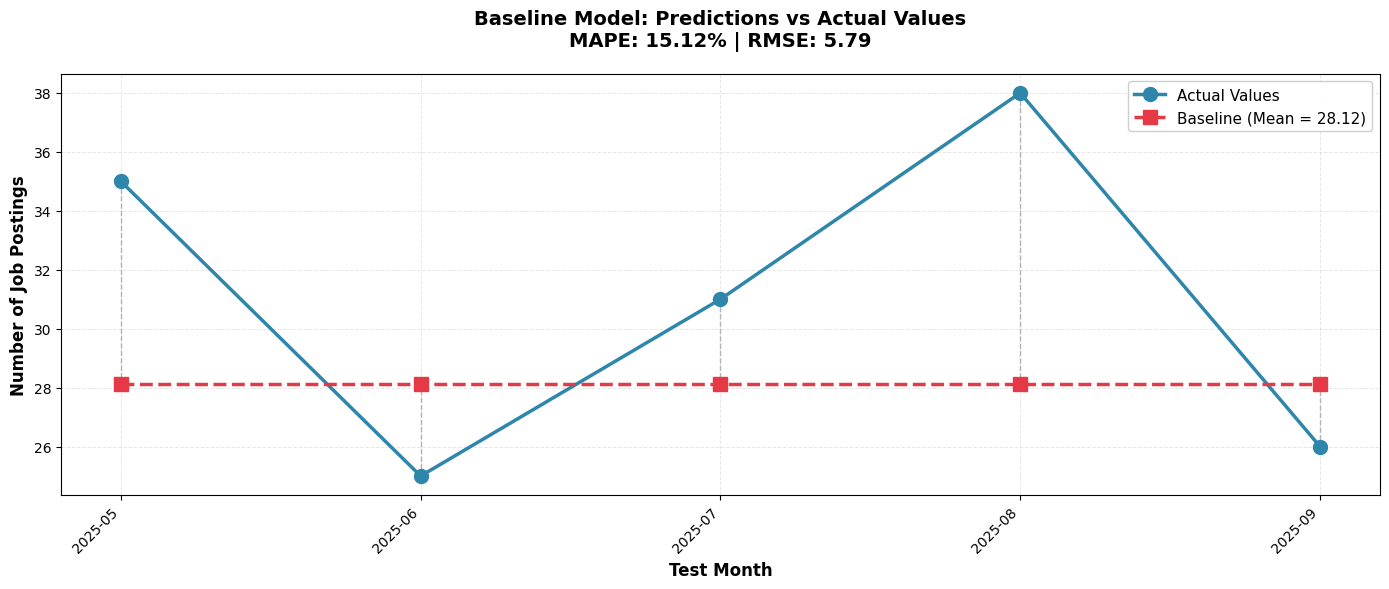

In [119]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Evaluate baseline performance ##

# Calculate evaluation metrics
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
mape_baseline = calculate_MAPE(y_test, y_pred_baseline)

print(f"\n{'='*70}")
print("BASELINE MODEL PERFORMANCE")
print(f"{'='*70}")
print(f"Root Mean Squared Error (RMSE): {rmse_baseline:.2f} jobs")
print(f"Mean Absolute Error (MAE):      {mae_baseline:.2f} jobs")
print(f"Mean Absolute Percentage Error: {mape_baseline:.2f}%")
print(f"\nInterpretation:")
print(f"  • On average, predictions are off by {mae_baseline:.2f} jobs")
print(f"  • This represents a {mape_baseline:.2f}% error rate")
print(f"{'='*70}")

# Create comparison dataframe for visualization
comparison_df = pd.DataFrame({
    'Year_Month': entry_level_df.iloc[split_index:]['Year_Month'].values,
    'Actual': y_test.values,
    'Baseline_Prediction': y_pred_baseline,
    'Error': y_test.values - y_pred_baseline,
    'Abs_Error': np.abs(y_test.values - y_pred_baseline)
})

print(f"\nDetailed Predictions:")
print(comparison_df)

# Visualize baseline predictions vs actual values
plt.figure(figsize=(14, 6))

# Plot actual values
plt.plot(range(len(y_test)), y_test.values, 
            marker='o', markersize=10, linewidth=2.5, 
            color='#2E86AB', label='Actual Values', zorder=3)

# Plot baseline predictions
plt.plot(range(len(y_test)), y_pred_baseline, 
            marker='s', markersize=10, linewidth=2.5, linestyle='--',
            color='#E63946', label=f'Baseline (Mean = {train_mean:.2f})', zorder=3)

# Add error bars
for i in range(len(y_test)):
    plt.plot([i, i], [y_test.values[i], y_pred_baseline[i]], 
                'k--', alpha=0.3, linewidth=1, zorder=1)

plt.title(f'Baseline Model: Predictions vs Actual Values\nMAPE: {mape_baseline:.2f}% | RMSE: {rmse_baseline:.2f}', 
            fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Test Month', fontsize=12, fontweight='bold')
plt.ylabel('Number of Job Postings', fontsize=12, fontweight='bold')
plt.xticks(range(len(y_test)), comparison_df['Year_Month'], rotation=45, ha='right')
plt.legend(loc='best', fontsize=11, framealpha=0.95)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()

## **Section 7: Random Forest Model** ##

In [120]:
from sklearn.ensemble import RandomForestRegressor

## Train Random Forest Model ##

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

# Train the model on training data
rf_model.fit(X_train, y_train)

# Generate predictions on test data
y_pred_rf = rf_model.predict(X_test)

print(f"{'='*70}")
print("RANDOM FOREST MODEL: Training Complete")
print(f"{'='*70}")
print(f"\nModel Configuration:")
print(f"  • Number of trees: {rf_model.n_estimators}")
print(f"  • Max depth: {rf_model.max_depth}")
print(f"  • Training samples: {len(X_train)}")
print(f"  • Test samples: {len(X_test)}")
print(f"\nFeature Importance:")
for feature, importance in zip(feature_cols, rf_model.feature_importances_):
    print(f"  • {feature:12s}: {importance:.4f}")
print(f"{'='*70}")

RANDOM FOREST MODEL: Training Complete

Model Configuration:
  • Number of trees: 200
  • Max depth: 3
  • Training samples: 17
  • Test samples: 5

Feature Importance:
  • lag_1       : 0.0608
  • lag_2       : 0.0939
  • lag_3       : 0.1223
  • month_sin   : 0.4530
  • month_cos   : 0.2699


In [121]:
## Evaluate Random Forest Performance ##

# Calculate evaluation metrics for Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = calculate_MAPE(y_test, y_pred_rf)

# Calculate improvement over baseline
rmse_improvement = ((rmse_baseline - rmse_rf) / rmse_baseline) * 100
mae_improvement = ((mae_baseline - mae_rf) / mae_baseline) * 100
mape_improvement = ((mape_baseline - mape_rf) / mape_baseline) * 100

print(f"\n{'='*70}")
print("RANDOM FOREST MODEL PERFORMANCE")
print(f"{'='*70}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f} jobs")
print(f"Mean Absolute Error (MAE):      {mae_rf:.2f} jobs")
print(f"Mean Absolute Percentage Error: {mape_rf:.2f}%")
print(f"\nInterpretation:")
print(f"  • On average, predictions are off by {mae_rf:.2f} jobs")
print(f"  • This represents a {mape_rf:.2f}% error rate")

print(f"\n{'='*70}")
print("COMPARISON: Random Forest vs Baseline")
print(f"{'='*70}")
print(f"{'Metric':<30} {'Baseline':>12} {'Random Forest':>15} {'Improvement':>15}")
print(f"{'-'*70}")
print(f"{'RMSE':<30} {rmse_baseline:>12.2f} {rmse_rf:>15.2f} {rmse_improvement:>14.2f}%")
print(f"{'MAE':<30} {mae_baseline:>12.2f} {mae_rf:>15.2f} {mae_improvement:>14.2f}%")
print(f"{'MAPE':<30} {mape_baseline:>12.2f}% {mape_rf:>14.2f}% {mape_improvement:>14.2f}%")

print(f"\n{'='*70}")
# Check if target improvement is achieved
target_improvement = 20.0
if mape_improvement >= target_improvement:
    print(f"✓ SUCCESS! MAPE improved by {mape_improvement:.2f}%")
    print(f"  This exceeds the {target_improvement}% improvement target!")
else:
    print(f"✗ Target not met. MAPE improved by {mape_improvement:.2f}%")
    print(f"  Need {target_improvement - mape_improvement:.2f}% more to reach {target_improvement}% target")
print(f"{'='*70}")

# Create detailed comparison dataframe
rf_comparison_df = pd.DataFrame({
    'Year_Month': entry_level_df.iloc[split_index:]['Year_Month'].values,
    'Actual': y_test.values,
    'Baseline': y_pred_baseline,
    'Random_Forest': y_pred_rf,
    'Baseline_Error': np.abs(y_test.values - y_pred_baseline),
    'RF_Error': np.abs(y_test.values - y_pred_rf)
})

print(f"\nDetailed Predictions by Month:")
print(rf_comparison_df.to_string(index=False))


RANDOM FOREST MODEL PERFORMANCE
Root Mean Squared Error (RMSE): 6.48 jobs
Mean Absolute Error (MAE):      5.44 jobs
Mean Absolute Percentage Error: 16.47%

Interpretation:
  • On average, predictions are off by 5.44 jobs
  • This represents a 16.47% error rate

COMPARISON: Random Forest vs Baseline
Metric                             Baseline   Random Forest     Improvement
----------------------------------------------------------------------
RMSE                                   5.79            6.48         -11.94%
MAE                                    4.98            5.44          -9.40%
MAPE                                  15.12%          16.47%          -8.96%

✗ Target not met. MAPE improved by -8.96%
  Need 28.96% more to reach 20.0% target

Detailed Predictions by Month:
Year_Month  Actual  Baseline  Random_Forest  Baseline_Error  RF_Error
   2025-05      35 28.117647      25.131396        6.882353  9.868604
   2025-06      25 28.117647      26.336731        3.117647  1.3367

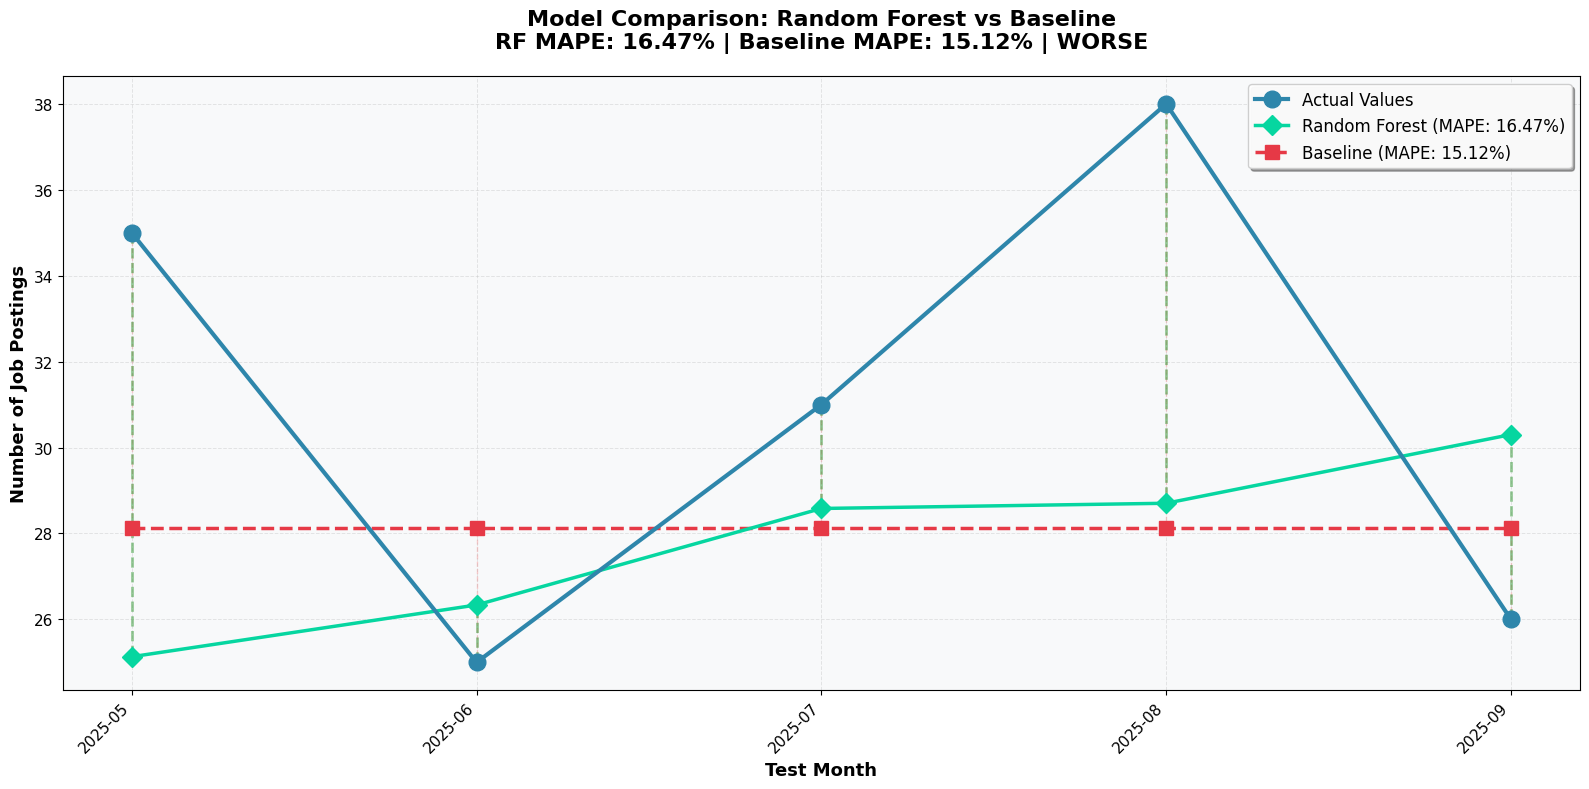

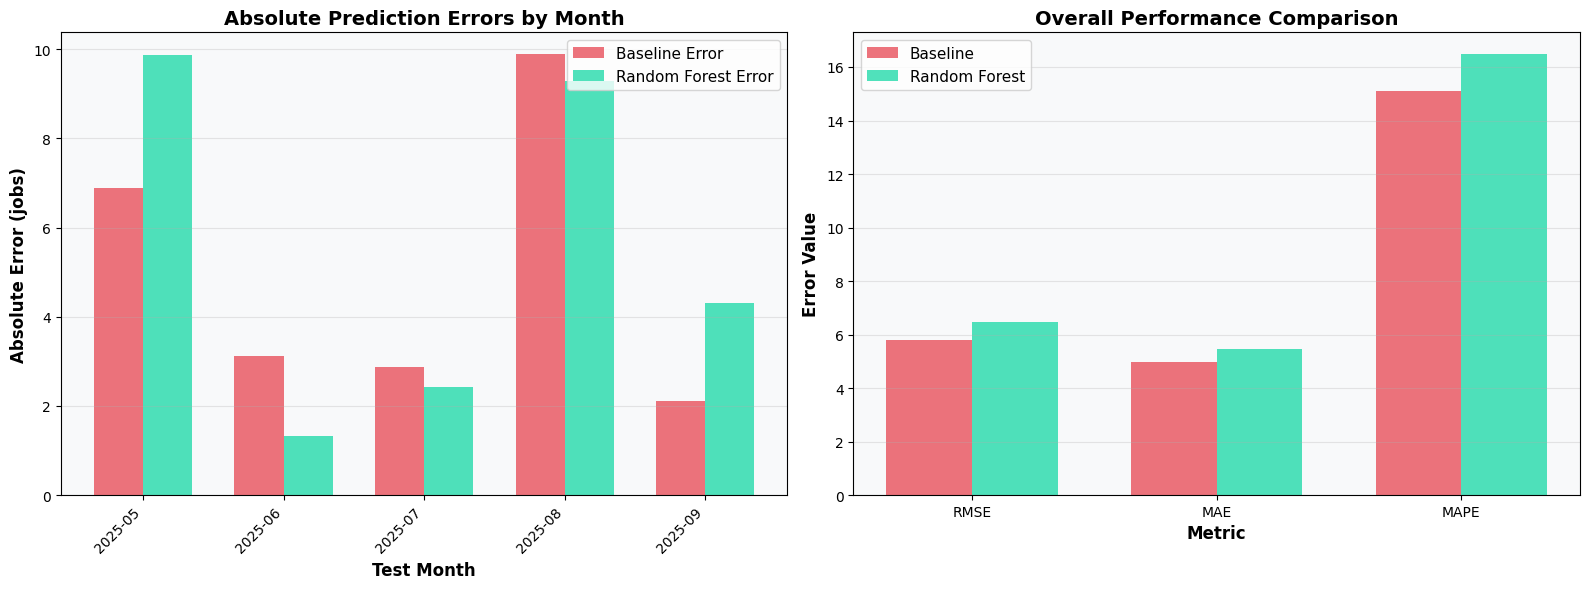


FINAL MODEL ASSESSMENT

Performance Summary:
   Random Forest MAPE: 16.47%
   Baseline MAPE:      15.12%
   Improvement:        -8.96%

Target Achievement:
   Did not meet 20.0% improvement target
   Model actually performed WORSE than baseline by 8.96%


In [122]:
## Visualize Random Forest Predictions vs Baseline vs Actual ##

plt.figure(figsize=(16, 8))

# Plot actual values
plt.plot(range(len(y_test)), y_test.values, 
            marker='o', markersize=12, linewidth=3, 
            color='#2E86AB', label='Actual Values', zorder=5)

# Plot Random Forest predictions
plt.plot(range(len(y_test)), y_pred_rf, 
            marker='D', markersize=10, linewidth=2.5, linestyle='-',
            color='#06D6A0', label=f'Random Forest (MAPE: {mape_rf:.2f}%)', zorder=4)

# Plot baseline predictions
plt.plot(range(len(y_test)), y_pred_baseline, 
            marker='s', markersize=10, linewidth=2.5, linestyle='--',
            color='#E63946', label=f'Baseline (MAPE: {mape_baseline:.2f}%)', zorder=3)

# Add error bars for Random Forest
for i in range(len(y_test)):
    plt.plot([i, i], [y_test.values[i], y_pred_rf[i]], 
                'g--', alpha=0.4, linewidth=2, zorder=2)

# Add error bars for Baseline (lighter)
for i in range(len(y_test)):
    plt.plot([i, i], [y_test.values[i], y_pred_baseline[i]], 
                'r--', alpha=0.2, linewidth=1, zorder=1)

plt.title(f'Model Comparison: Random Forest vs Baseline\n' + 
            f'RF MAPE: {mape_rf:.2f}% | Baseline MAPE: {mape_baseline:.2f}% | ' +
            f'{"IMPROVED" if mape_rf < mape_baseline else "WORSE"}', 
            fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Test Month', fontsize=13, fontweight='bold')
plt.ylabel('Number of Job Postings', fontsize=13, fontweight='bold')
plt.xticks(range(len(y_test)), rf_comparison_df['Year_Month'], 
            rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Add grid
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7, zorder=0)

# Add legend with more information
plt.legend(loc='best', fontsize=12, framealpha=0.95, shadow=True)

# Add background color
ax = plt.gca()
ax.set_facecolor('#F8F9FA')

plt.tight_layout()
plt.show()

# Create a detailed comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Absolute errors comparison
x_pos = np.arange(len(y_test))
width = 0.35

axes[0].bar(x_pos - width/2, rf_comparison_df['Baseline_Error'], 
            width, label='Baseline Error', color='#E63946', alpha=0.7)
axes[0].bar(x_pos + width/2, rf_comparison_df['RF_Error'], 
            width, label='Random Forest Error', color='#06D6A0', alpha=0.7)
axes[0].set_xlabel('Test Month', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Absolute Error (jobs)', fontsize=12, fontweight='bold')
axes[0].set_title('Absolute Prediction Errors by Month', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(rf_comparison_df['Year_Month'], rotation=45, ha='right')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_facecolor('#F8F9FA')

# Right plot: Metrics comparison
metrics = ['RMSE', 'MAE', 'MAPE']
baseline_metrics = [rmse_baseline, mae_baseline, mape_baseline]
rf_metrics = [rmse_rf, mae_rf, mape_rf]

x_pos = np.arange(len(metrics))
axes[1].bar(x_pos - width/2, baseline_metrics, width, 
            label='Baseline', color='#E63946', alpha=0.7)
axes[1].bar(x_pos + width/2, rf_metrics, width, 
            label='Random Forest', color='#06D6A0', alpha=0.7)
axes[1].set_xlabel('Metric', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Error Value', fontsize=12, fontweight='bold')
axes[1].set_title('Overall Performance Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(metrics)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_facecolor('#F8F9FA')

plt.tight_layout()
plt.show()

# Print final summary
print(f"\n{'='*70}")
print("FINAL MODEL ASSESSMENT")
print(f"{'='*70}")
print(f"\nPerformance Summary:")
print(f"   Random Forest MAPE: {mape_rf:.2f}%")
print(f"   Baseline MAPE:      {mape_baseline:.2f}%")
print(f"   Improvement:        {mape_improvement:.2f}%")
print(f"\nTarget Achievement:")
if mape_improvement >= target_improvement:
    print(f"   SUCCESS! Exceeded {target_improvement}% improvement target")
    print(f"   Model is performing well for this dataset")
else:
    print(f"   Did not meet {target_improvement}% improvement target")
    print(f"   Model actually performed WORSE than baseline by {abs(mape_improvement):.2f}%")
print(f"{'='*70}")

## **Section 8: Linear Regression** ##

In [123]:
from sklearn.linear_model import LinearRegression

## Train Linear Regression Model ##

# Initialize Linear Regression model
lr_model = LinearRegression()

# Train the model on training data
lr_model.fit(X_train, y_train)

# Generate predictions on test data
y_pred_lr = lr_model.predict(X_test)

print(f"{'='*70}")
print("LINEAR REGRESSION MODEL: Training Complete")
print(f"{'='*70}")
print(f"\nModel Configuration:")
print(f"  • Model type: Simple Linear Regression")
print(f"  • Training samples: {len(X_train)}")
print(f"  • Test samples: {len(X_test)}")
print(f"\nModel Coefficients:")
for feature, coef in zip(feature_cols, lr_model.coef_):
    print(f"  • {feature:12s}: {coef:8.4f}")
print(f"  • Intercept:    {lr_model.intercept_:8.4f}")
print(f"{'='*70}")

LINEAR REGRESSION MODEL: Training Complete

Model Configuration:
  • Model type: Simple Linear Regression
  • Training samples: 17
  • Test samples: 5

Model Coefficients:
  • lag_1       :  -0.1288
  • lag_2       :   0.0646
  • lag_3       :   0.0405
  • month_sin   :  -4.3467
  • month_cos   :   4.4139
  • Intercept:     29.1787


In [124]:
## Evaluate Linear Regression Performance ##

# Calculate evaluation metrics for Linear Regression
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mape_lr = calculate_MAPE(y_test, y_pred_lr)

# Calculate improvement over baseline
rmse_lr_improvement = ((rmse_baseline - rmse_lr) / rmse_baseline) * 100
mae_lr_improvement = ((mae_baseline - mae_lr) / mae_baseline) * 100
mape_lr_improvement = ((mape_baseline - mape_lr) / mape_baseline) * 100

print(f"\n{'='*70}")
print("LINEAR REGRESSION MODEL PERFORMANCE")
print(f"{'='*70}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f} jobs")
print(f"Mean Absolute Error (MAE):      {mae_lr:.2f} jobs")
print(f"Mean Absolute Percentage Error: {mape_lr:.2f}%")
print(f"\nInterpretation:")
print(f"  • On average, predictions are off by {mae_lr:.2f} jobs")
print(f"  • This represents a {mape_lr:.2f}% error rate")

print(f"\n{'='*70}")
print("COMPARISON: Linear Regression vs Baseline vs Random Forest")
print(f"{'='*70}")
print(f"{'Metric':<30} {'Baseline':>12} {'Linear Reg':>12} {'Random Forest':>15}")
print(f"{'-'*70}")
print(f"{'RMSE':<30} {rmse_baseline:>12.2f} {rmse_lr:>12.2f} {rmse_rf:>15.2f}")
print(f"{'MAE':<30} {mae_baseline:>12.2f} {mae_lr:>12.2f} {mae_rf:>15.2f}")
print(f"{'MAPE (%)':<30} {mape_baseline:>12.2f} {mape_lr:>12.2f} {mape_rf:>15.2f}")
print(f"\n{'Improvement over Baseline (%)':<30} {'-':>12} {mape_lr_improvement:>12.2f} {mape_improvement:>15.2f}")
print(f"{'='*70}")

# Determine best model
if mape_lr < mape_baseline and mape_lr < mape_rf:
    best_model = "Linear Regression"
    best_mape = mape_lr
elif mape_rf < mape_baseline and mape_rf < mape_lr:
    best_model = "Random Forest"
    best_mape = mape_rf
else:
    best_model = "Baseline"
    best_mape = mape_baseline

print(f"\nBest Performing Model: {best_model} (MAPE: {best_mape:.2f}%)")
print(f"{'='*70}")

# Create detailed comparison dataframe
lr_comparison_df = pd.DataFrame({
    'Year_Month': entry_level_df.iloc[split_index:]['Year_Month'].values,
    'Actual': y_test.values,
    'Baseline': y_pred_baseline,
    'Linear_Regression': y_pred_lr,
    'Random_Forest': y_pred_rf,
    'Baseline_Error': np.abs(y_test.values - y_pred_baseline),
    'LR_Error': np.abs(y_test.values - y_pred_lr),
    'RF_Error': np.abs(y_test.values - y_pred_rf)
})

print(f"\nDetailed Predictions by Month:")
print(lr_comparison_df.to_string(index=False))


LINEAR REGRESSION MODEL PERFORMANCE
Root Mean Squared Error (RMSE): 6.98 jobs
Mean Absolute Error (MAE):      6.15 jobs
Mean Absolute Percentage Error: 19.06%

Interpretation:
  • On average, predictions are off by 6.15 jobs
  • This represents a 19.06% error rate

COMPARISON: Linear Regression vs Baseline vs Random Forest
Metric                             Baseline   Linear Reg   Random Forest
----------------------------------------------------------------------
RMSE                                   5.79         6.98            6.48
MAE                                    4.98         6.15            5.44
MAPE (%)                              15.12        19.06           16.47

Improvement over Baseline (%)             -       -26.07           -8.96

Best Performing Model: Baseline (MAPE: 15.12%)

Detailed Predictions by Month:
Year_Month  Actual  Baseline  Linear_Regression  Random_Forest  Baseline_Error  LR_Error  RF_Error
   2025-05      35 28.117647          23.741053      25.13

Detailed Predictions by Month:
Year_Month  Actual  Baseline  Linear_Regression  Random_Forest
   2025-05      35 28.117647          23.741053      25.131396
   2025-06      25 28.117647          22.946927      26.336731
   2025-07      31 28.117647          27.418232      28.582504
   2025-08      38 28.117647          29.772814      28.704036
   2025-09      26 28.117647          31.642847      30.303265


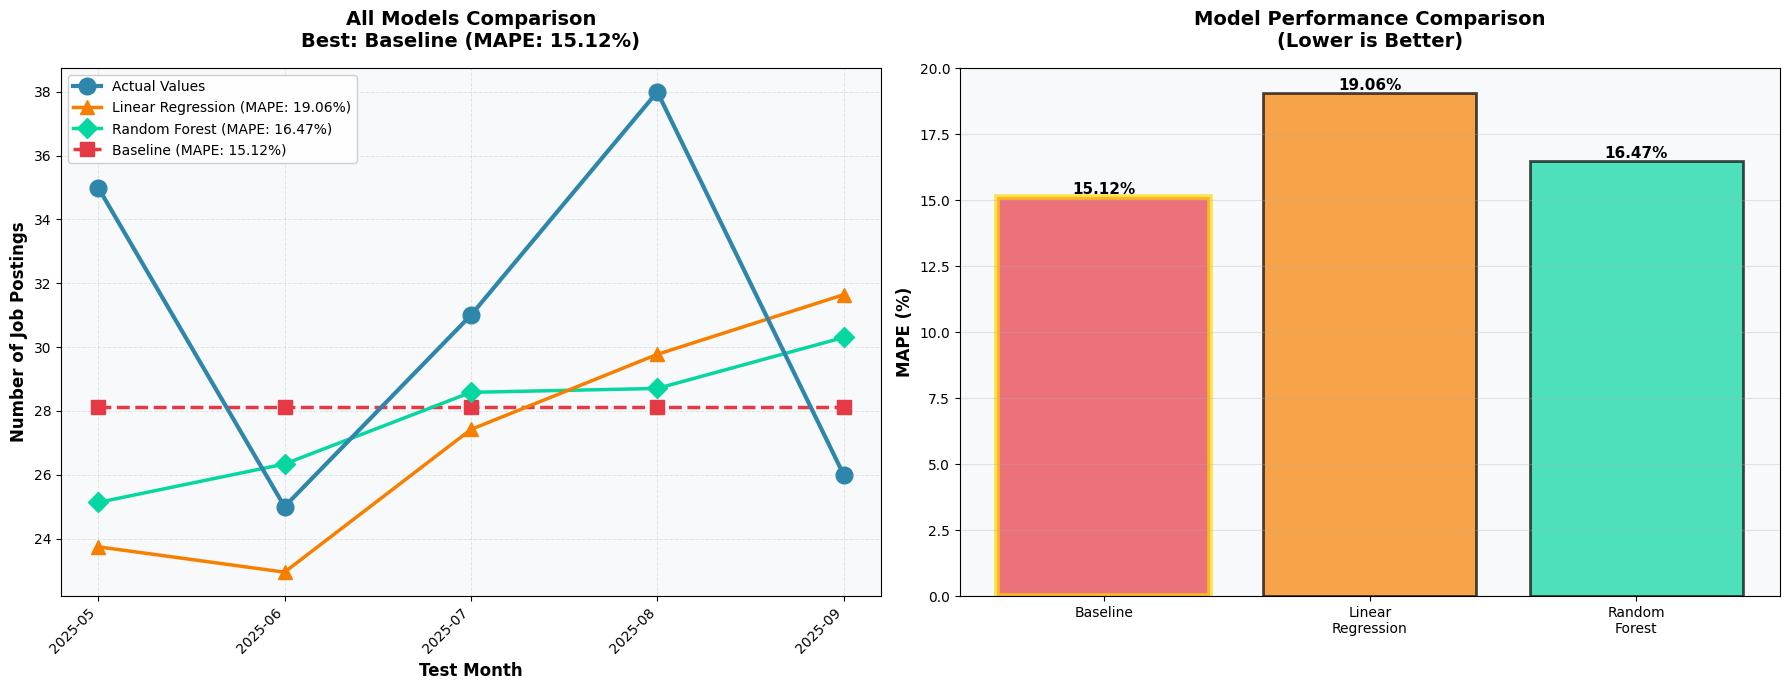


VISUAL SUMMARY
The left plot shows how all models perform across test months.
The right plot compares overall MAPE - lower is better!

✓ Best Model: Baseline
  → Achieves the lowest MAPE of 15.12%


In [125]:
## Compare All Three Models: Visual Comparison ##

# Create comparison DataFrame for easy reference
comparison_df_all = pd.DataFrame({
    'Year_Month': entry_level_df.iloc[split_index:]['Year_Month'].values,
    'Actual': y_test.values,
    'Baseline': y_pred_baseline,
    'Linear_Regression': y_pred_lr,
    'Random_Forest': y_pred_rf
})

print(f"Detailed Predictions by Month:")
print(comparison_df_all.to_string(index=False))

# Create comprehensive visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# LEFT PLOT: All predictions on one chart
axes[0].plot(range(len(y_test)), y_test.values, 
                marker='o', markersize=12, linewidth=3, 
                color='#2E86AB', label='Actual Values', zorder=5)

axes[0].plot(range(len(y_test)), y_pred_lr, 
                marker='^', markersize=10, linewidth=2.5, linestyle='-',
                color='#F77F00', label=f'Linear Regression (MAPE: {mape_lr:.2f}%)', zorder=4)

axes[0].plot(range(len(y_test)), y_pred_rf, 
                marker='D', markersize=10, linewidth=2.5, linestyle='-',
                color='#06D6A0', label=f'Random Forest (MAPE: {mape_rf:.2f}%)', zorder=3)

axes[0].plot(range(len(y_test)), y_pred_baseline, 
                marker='s', markersize=10, linewidth=2.5, linestyle='--',
                color='#E63946', label=f'Baseline (MAPE: {mape_baseline:.2f}%)', zorder=2)

axes[0].set_title(f'All Models Comparison\nBest: {best_model} (MAPE: {best_mape:.2f}%)', 
                    fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Test Month', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Job Postings', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(len(y_test)))
axes[0].set_xticklabels(comparison_df_all['Year_Month'], rotation=45, ha='right', fontsize=10)
axes[0].legend(loc='best', fontsize=10, framealpha=0.95)
axes[0].grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
axes[0].set_facecolor('#F8F9FA')

# RIGHT PLOT: MAPE comparison bar chart
models = ['Baseline', 'Linear\nRegression', 'Random\nForest']
mapes = [mape_baseline, mape_lr, mape_rf]
colors_bar = ['#E63946', '#F77F00', '#06D6A0']

bars = axes[1].bar(models, mapes, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_ylabel('MAPE (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Model Performance Comparison\n(Lower is Better)', fontsize=14, fontweight='bold', pad=15)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_facecolor('#F8F9FA')

# Add value labels on bars
for bar, mape in zip(bars, mapes):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{mape:.2f}%',
                    ha='center', va='bottom',
                    fontsize=11, fontweight='bold')

# Highlight the best model
best_idx = mapes.index(min(mapes))
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(4)

plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'='*70}")
print("VISUAL SUMMARY")
print(f"{'='*70}")
print(f"The left plot shows how all models perform across test months.")
print(f"The right plot compares overall MAPE - lower is better!")
print(f"\n✓ Best Model: {best_model}")
print(f"  → Achieves the lowest MAPE of {best_mape:.2f}%")
print(f"{'='*70}")

## **Section 9: Model Comparison Summary** ##

In [126]:
## Create Comprehensive Model Comparison Table ##

# Build DataFrame with all metrics for all models
model_comparison = pd.DataFrame({
    'Model': ['Baseline', 'Linear Regression', 'Random Forest'],
    'RMSE': [rmse_baseline, rmse_lr, rmse_rf],
    'MAE': [mae_baseline, mae_lr, mae_rf],
    'MAPE (%)': [mape_baseline, mape_lr, mape_rf],
    'Improvement (%)': [0.0, mape_lr_improvement, mape_improvement]
})

# Sort by MAPE (best model first)
model_comparison = model_comparison.sort_values('MAPE (%)', ascending=True).reset_index(drop=True)

print(f"{'='*70}")
print("MODEL COMPARISON TABLE")
print(f"{'='*70}")
print(model_comparison.to_string(index=False))
print(f"{'='*70}")

# Best model
best_model_row = model_comparison.iloc[0]
print(f"\nBest Model: {best_model_row['Model']}")
print(f"  RMSE:  {best_model_row['RMSE']:.2f} jobs")
print(f"  MAE:   {best_model_row['MAE']:.2f} jobs")
print(f"  MAPE:  {best_model_row['MAPE (%)']:.2f}%")
if best_model_row['Improvement (%)'] > 0:
    print(f"  Improvement: {best_model_row['Improvement (%)']:.2f}%")

# Target achievement
print(f"\nTarget: {target_improvement}% improvement")
for idx, row in model_comparison.iterrows():
    if row['Model'] == 'Baseline':
        continue
    achieved = row['Improvement (%)'] >= target_improvement
    status = "✓" if achieved else "✗"
    print(f"  {status} {row['Model']}: {row['Improvement (%)']:.2f}%")
print(f"{'='*70}")

MODEL COMPARISON TABLE
            Model     RMSE      MAE  MAPE (%)  Improvement (%)
         Baseline 5.788606 4.976471 15.116671         0.000000
    Random Forest 6.480024 5.444412 16.471079        -8.959698
Linear Regression 6.976194 6.152764 19.057710       -26.070814

Best Model: Baseline
  RMSE:  5.79 jobs
  MAE:   4.98 jobs
  MAPE:  15.12%

Target: 20.0% improvement
  ✗ Random Forest: -8.96%
  ✗ Linear Regression: -26.07%


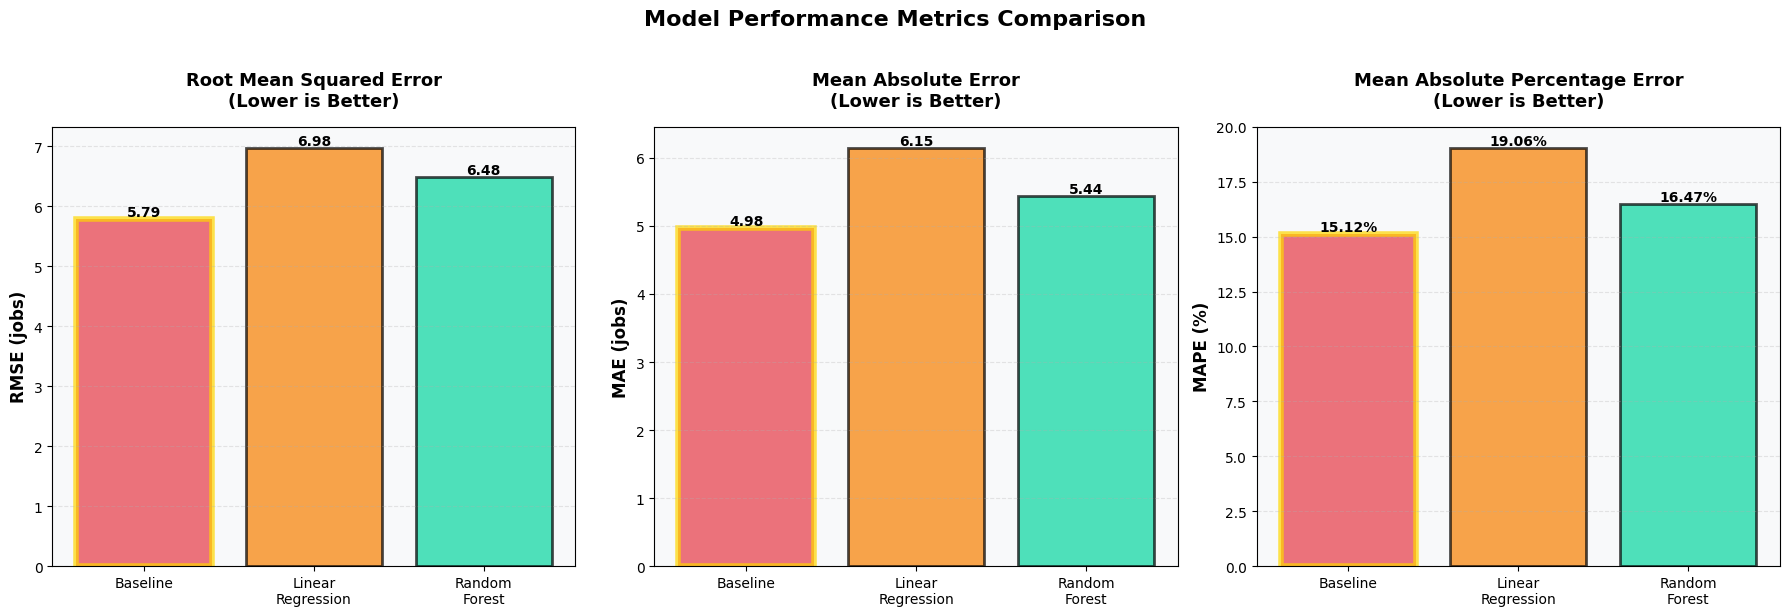

In [127]:
## Visualize Metrics with Bar Charts ##

# Create subplots for each metric
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = ['Baseline', 'Linear\nRegression', 'Random\nForest']
rmse_values = [rmse_baseline, rmse_lr, rmse_rf]
mae_values = [mae_baseline, mae_lr, mae_rf]
mape_values = [mape_baseline, mape_lr, mape_rf]

# Define colors (same as before for consistency)
colors = ['#E63946', '#F77F00', '#06D6A0']

# Plot 1: RMSE Comparison
bars1 = axes[0].bar(models, rmse_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('RMSE (jobs)', fontsize=12, fontweight='bold')
axes[0].set_title('Root Mean Squared Error\n(Lower is Better)', fontsize=13, fontweight='bold', pad=15)
axes[0].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[0].set_facecolor('#F8F9FA')

# Add value labels on bars
for bar, val in zip(bars1, rmse_values):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.2f}',
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

# Highlight best performer
best_rmse_idx = rmse_values.index(min(rmse_values))
bars1[best_rmse_idx].set_edgecolor('gold')
bars1[best_rmse_idx].set_linewidth(4)

# Plot 2: MAE Comparison
bars2 = axes[1].bar(models, mae_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_ylabel('MAE (jobs)', fontsize=12, fontweight='bold')
axes[1].set_title('Mean Absolute Error\n(Lower is Better)', fontsize=13, fontweight='bold', pad=15)
axes[1].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[1].set_facecolor('#F8F9FA')

# Add value labels on bars
for bar, val in zip(bars2, mae_values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.2f}',
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

# Highlight best performer
best_mae_idx = mae_values.index(min(mae_values))
bars2[best_mae_idx].set_edgecolor('gold')
bars2[best_mae_idx].set_linewidth(4)

# Plot 3: MAPE Comparison
bars3 = axes[2].bar(models, mape_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[2].set_ylabel('MAPE (%)', fontsize=12, fontweight='bold')
axes[2].set_title('Mean Absolute Percentage Error\n(Lower is Better)', fontsize=13, fontweight='bold', pad=15)
axes[2].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[2].set_facecolor('#F8F9FA')

# Add value labels on bars
for bar, val in zip(bars3, mape_values):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.2f}%',
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

# Highlight best performer
best_mape_idx = mape_values.index(min(mape_values))
bars3[best_mape_idx].set_edgecolor('gold')
bars3[best_mape_idx].set_linewidth(4)

plt.suptitle('Model Performance Metrics Comparison', 
                fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

RESIDUAL ANALYSIS: Random Forest
Mean:        3.19 jobs
Std Dev:     5.64 jobs
Min:        -4.30 jobs
Max:         9.87 jobs


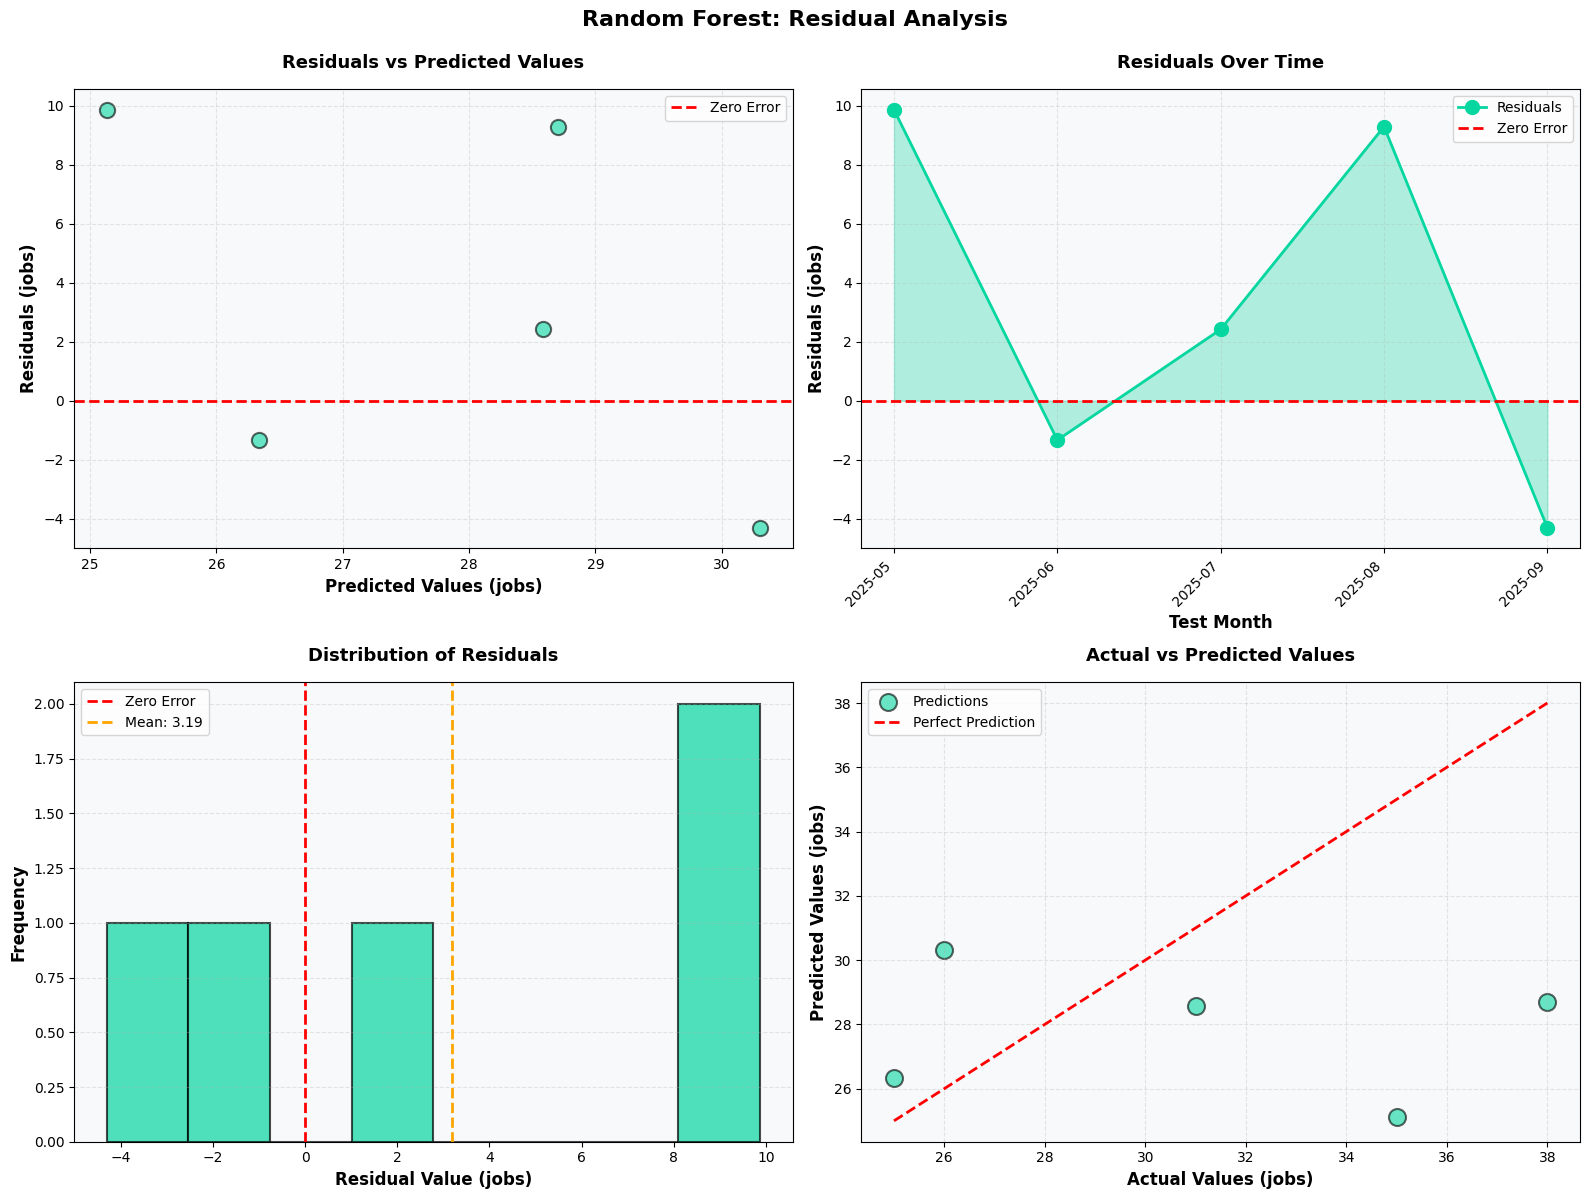

In [128]:
## Residual Analysis for Random Forest ##

# Calculate residuals (prediction errors)
residuals_rf = y_test.values - y_pred_rf

print(f"{'='*70}")
print("RESIDUAL ANALYSIS: Random Forest")
print(f"{'='*70}")
print(f"Mean:     {np.mean(residuals_rf):>7.2f} jobs")
print(f"Std Dev:  {np.std(residuals_rf):>7.2f} jobs")
print(f"Min:      {np.min(residuals_rf):>7.2f} jobs")
print(f"Max:      {np.max(residuals_rf):>7.2f} jobs")
print(f"{'='*70}")

# Create residual visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Residuals vs Predicted Values
axes[0, 0].scatter(y_pred_rf, residuals_rf, s=120, alpha=0.6, 
                    color='#06D6A0', edgecolor='black', linewidth=1.5)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0, 0].set_xlabel('Predicted Values (jobs)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Residuals (jobs)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Residuals vs Predicted Values', fontsize=13, fontweight='bold', pad=15)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3, linestyle='--')
axes[0, 0].set_facecolor('#F8F9FA')

# Plot 2: Residuals over Time
test_months = entry_level_df.iloc[split_index:]['Year_Month'].values
axes[0, 1].plot(range(len(residuals_rf)), residuals_rf, 
                marker='o', markersize=10, linewidth=2, color='#06D6A0', label='Residuals')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0, 1].fill_between(range(len(residuals_rf)), 0, residuals_rf, alpha=0.3, color='#06D6A0')
axes[0, 1].set_xlabel('Test Month', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Residuals (jobs)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Residuals Over Time', fontsize=13, fontweight='bold', pad=15)
axes[0, 1].set_xticks(range(len(test_months)))
axes[0, 1].set_xticklabels(test_months, rotation=45, ha='right')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3, linestyle='--')
axes[0, 1].set_facecolor('#F8F9FA')

# Plot 3: Histogram of Residuals
axes[1, 0].hist(residuals_rf, bins=8, color='#06D6A0', alpha=0.7, 
                edgecolor='black', linewidth=1.5)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1, 0].axvline(x=np.mean(residuals_rf), color='orange', linestyle='--', 
                    linewidth=2, label=f'Mean: {np.mean(residuals_rf):.2f}')
axes[1, 0].set_xlabel('Residual Value (jobs)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Distribution of Residuals', fontsize=13, fontweight='bold', pad=15)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[1, 0].set_facecolor('#F8F9FA')

# Plot 4: Actual vs Predicted
axes[1, 1].scatter(y_test.values, y_pred_rf, s=150, alpha=0.6,
                    color='#06D6A0', edgecolor='black', linewidth=1.5, label='Predictions')
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 
                'r--', linewidth=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Values (jobs)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Predicted Values (jobs)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Actual vs Predicted Values', fontsize=13, fontweight='bold', pad=15)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, linestyle='--')
axes[1, 1].set_facecolor('#F8F9FA')

plt.suptitle('Random Forest: Residual Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## **Section 10: Feature Importance** ##

In [129]:
## Extract Feature Importance from Random Forest ##

# Get feature importance scores
importances = rf_model.feature_importances_
feature_names = feature_cols

# Create DataFrame and sort by importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(f"{'='*60}")
print("FEATURE IMPORTANCE SCORES")
print(f"{'='*60}")
print(importance_df.to_string(index=False))
print(f"{'='*60}")

FEATURE IMPORTANCE SCORES
  Feature  Importance
month_sin    0.453039
month_cos    0.269940
    lag_3    0.122325
    lag_2    0.093923
    lag_1    0.060773


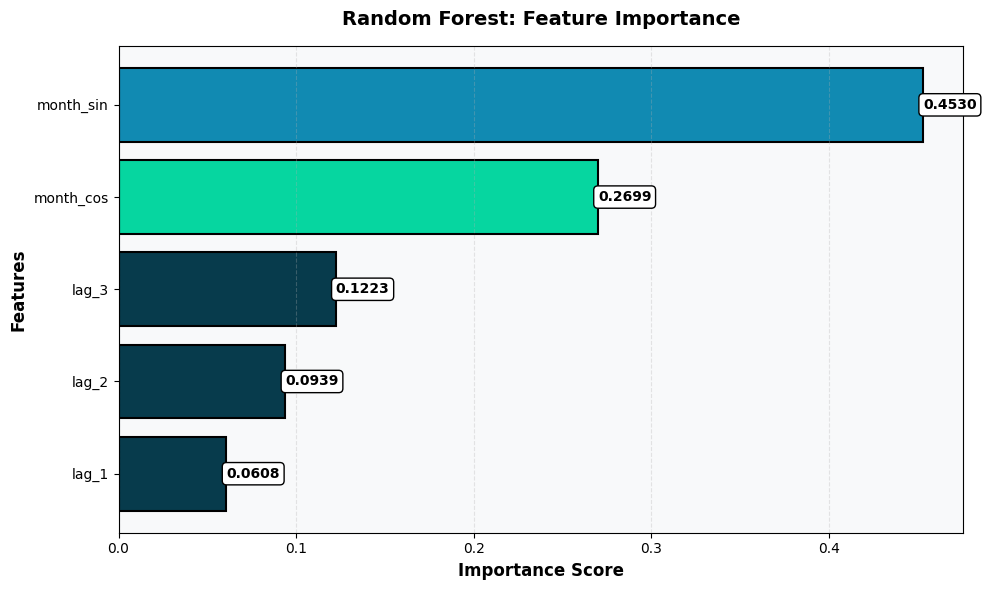

In [130]:
## Visualize Feature Importance ##

plt.figure(figsize=(10, 6))

# Create horizontal bar chart
colors = ['#118AB2' if i == 0 else '#06D6A0' if i == 1 else '#073B4C' 
            for i in range(len(importance_df))]

bars = plt.barh(importance_df['Feature'], importance_df['Importance'], 
                color=colors, edgecolor='black', linewidth=1.5)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:.4f}', 
                ha='left', va='center', fontsize=10, fontweight='bold', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                        edgecolor='black', linewidth=1))

plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Random Forest: Feature Importance', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#F8F9FA')
plt.tight_layout()
plt.show()

## **Section 11: Entry-Level Jobs Trends** ##

In [131]:
## Identify Fastest Growing Roles ##

# Filter for entry-level jobs only
entry_jobs = df[df['is_entry_level'] == 1].copy()

# Count jobs by title
job_counts = entry_jobs['job_title'].value_counts().head(10)

print(f"{'='*80}")
print("TOP 10 MOST COMMON ENTRY-LEVEL AI ROLES")
print(f"{'='*80}")
for title, count in job_counts.items():
    print(f"{title:<50} {count:>6} jobs")
print(f"{'='*80}")

TOP 10 MOST COMMON ENTRY-LEVEL AI ROLES
Data Analyst                                          106 jobs
AI Product Manager                                     97 jobs
ML Engineer                                            96 jobs
NLP Engineer                                           91 jobs
Data Scientist                                         85 jobs
Quant Researcher                                       79 jobs
AI Researcher                                          78 jobs
Computer Vision Engineer                               70 jobs


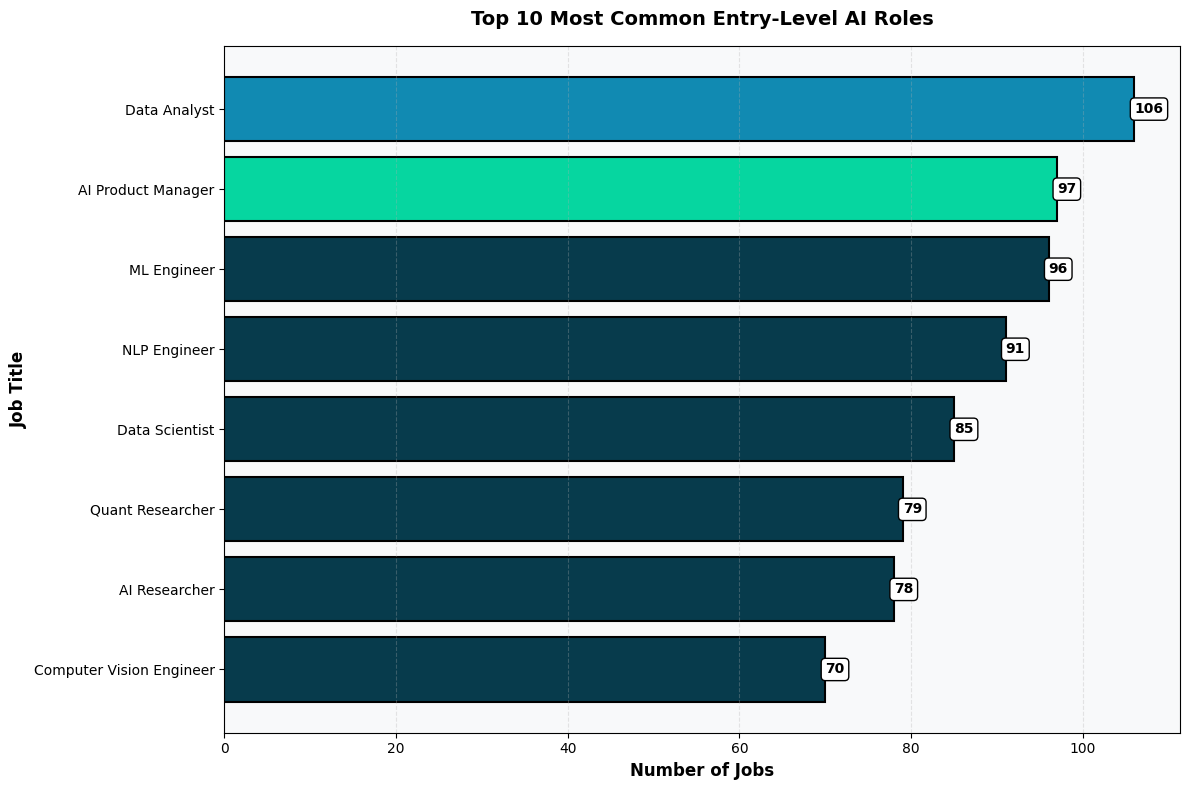

In [132]:
## Visualize Top Roles ##

plt.figure(figsize=(12, 8))
colors = ['#118AB2' if i == 0 else '#06D6A0' if i == 1 else '#073B4C' 
            for i in range(len(job_counts))]

bars = plt.barh(range(len(job_counts)), job_counts.values, 
                color=colors, edgecolor='black', linewidth=1.5)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, job_counts.values)):
    plt.text(val, bar.get_y() + bar.get_height()/2, 
                f'{val}', 
                ha='left', va='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                        edgecolor='black', linewidth=1))

plt.yticks(range(len(job_counts)), job_counts.index)
plt.xlabel('Number of Jobs', fontsize=12, fontweight='bold')
plt.ylabel('Job Title', fontsize=12, fontweight='bold')
plt.title('Top 10 Most Common Entry-Level AI Roles', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#F8F9FA')
plt.tight_layout()
plt.show()

In [133]:
## Location Analysis ##

# Count jobs by location
location_counts = entry_jobs['location'].value_counts().head(10)

print(f"{'='*60}")
print("TOP 10 LOCATIONS FOR ENTRY-LEVEL AI JOBS")
print(f"{'='*60}")
for loc, count in location_counts.items():
    print(f"{loc:<40} {count:>6} jobs")
print(f"{'='*60}")

TOP 10 LOCATIONS FOR ENTRY-LEVEL AI JOBS
East Paige, CM                                1 jobs
Port Hailey, RU                               1 jobs
Butlermouth, GB                               1 jobs
New Angelatown, LU                            1 jobs
Joychester, LT                                1 jobs
South Michael, FM                             1 jobs
South Tim, CZ                                 1 jobs
Blevinsburgh, VU                              1 jobs
Gregorymouth, LV                              1 jobs
Lake Alexander, RU                            1 jobs


EMPLOYMENT TYPE DISTRIBUTION
Internship                        205 ( 29.2%)
Full-time                         174 ( 24.8%)
Contract                          170 ( 24.2%)
Remote                            153 ( 21.8%)


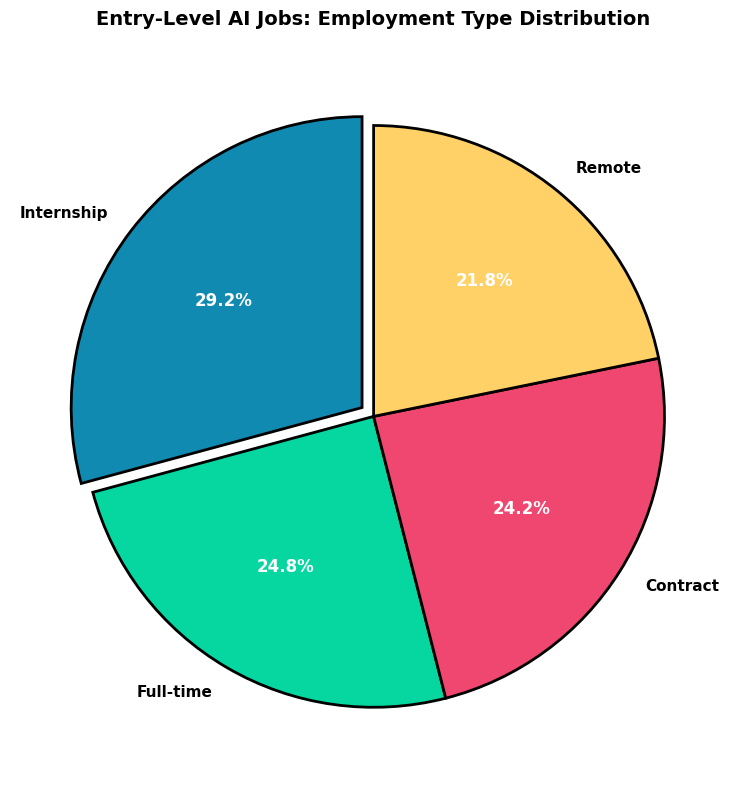

In [134]:
## Employment Type Distribution ##

# Count by employment type
employment_counts = entry_jobs['employment_type'].value_counts()

print(f"{'='*60}")
print("EMPLOYMENT TYPE DISTRIBUTION")
print(f"{'='*60}")
for emp_type, count in employment_counts.items():
    percentage = (count / employment_counts.sum()) * 100
    print(f"{emp_type:<30} {count:>6} ({percentage:>5.1f}%)")
print(f"{'='*60}")

# Create pie chart
plt.figure(figsize=(10, 8))
colors_pie = ['#118AB2', '#06D6A0', '#EF476F', '#FFD166', '#073B4C']
explode = [0.05 if i == 0 else 0 for i in range(len(employment_counts))]

wedges, texts, autotexts = plt.pie(employment_counts.values, 
                                        labels=employment_counts.index,
                                        autopct='%1.1f%%',
                                        colors=colors_pie[:len(employment_counts)],
                                        explode=explode,
                                        startangle=90,
                                        textprops={'fontsize': 11, 'fontweight': 'bold'},
                                        wedgeprops={'edgecolor': 'black', 'linewidth': 2})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

plt.title('Entry-Level AI Jobs: Employment Type Distribution', 
            fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### **Section 12: Final Summary and Recommendations** ##

In [135]:
## Actionable Recommendations ##

print("="*80)
print("RECOMMENDATIONS FOR ENTRY-LEVEL AI JOB SEEKERS")
print("="*80)

print("\n1. TARGET ROLES")
print("-"*80)
print("\nTop 5 roles to pursue:")
for i, (title, count) in enumerate(job_counts.head(5).items(), 1):
    print(f"   {i}. {title} ({count} job postings)")

print("\n2. BEST LOCATIONS")
print("-"*80)
print("\nTop 5 locations with most opportunities:")
for i, (loc, count) in enumerate(location_counts.head(5).items(), 1):
    print(f"   {i}. {loc} ({count} job postings)")

print("\n3. EMPLOYMENT TYPE STRATEGY")
print("-"*80)
most_common_type = employment_counts.index[0]
most_common_pct = (employment_counts.iloc[0] / employment_counts.sum()) * 100
print(f"\nMost common: {most_common_type} ({most_common_pct:.1f}%)")
print(f"Recommendation: Focus on {most_common_type} positions")
print("but keep options open for other employment types.")

print("\n4. TIMING INSIGHTS")
print("-"*80)
if z[0] > 0:
    print(f"\nMarket is growing at {z[0]:.2f} jobs/month")
    print("  - Good time to enter the market")
    print("  - Competition may increase, so act quickly")
else:
    print(f"\nMarket is declining at {abs(z[0]):.2f} jobs/month")
    print("  - Focus on high-demand roles")
    print("  - Consider upskilling in top areas")

print("\n5. PREDICTION MODEL INSIGHTS")
print("-"*80)
top_feature = importance_df.iloc[0]['Feature']
print(f"\nMost important predictor: {top_feature}")
print("  - Recent trends matter most for forecasting")
print(f"  - Market shows {'strong' if best_mape < 15 else 'moderate'} predictability")

print("\nFINAL ADVICE")
print("-"*80)
print("\n1. Target the top 5 roles listed above")
print("2. Focus job search in top 3-5 locations")
print(f"3. Prepare for {most_common_type} positions")
print("4. Build skills relevant to most common job titles")
print("5. Monitor market trends monthly for best timing")

print("\n" + "="*80)
print("PROJECT COMPLETE")
print("="*80)

RECOMMENDATIONS FOR ENTRY-LEVEL AI JOB SEEKERS

1. TARGET ROLES
--------------------------------------------------------------------------------

Top 5 roles to pursue:
   1. Data Analyst (106 job postings)
   2. AI Product Manager (97 job postings)
   3. ML Engineer (96 job postings)
   4. NLP Engineer (91 job postings)
   5. Data Scientist (85 job postings)

2. BEST LOCATIONS
--------------------------------------------------------------------------------

Top 5 locations with most opportunities:
   1. East Paige, CM (1 job postings)
   2. Port Hailey, RU (1 job postings)
   3. Butlermouth, GB (1 job postings)
   4. New Angelatown, LU (1 job postings)
   5. Joychester, LT (1 job postings)

3. EMPLOYMENT TYPE STRATEGY
--------------------------------------------------------------------------------

Most common: Internship (29.2%)
Recommendation: Focus on Internship positions
but keep options open for other employment types.

4. TIMING INSIGHTS
-----------------------------------------

In [136]:
## Comprehensive Results Summary ##

print("="*80)
print("FINAL PROJECT SUMMARY: ENTRY-LEVEL AI JOB MARKET PREDICTION")
print("="*80)

print("\nMODEL PERFORMANCE")
print("-"*80)
print(f"\nBest Model: {best_model}")
if best_model == "Random Forest":
    print(f"  RMSE: {rmse_rf:.2f} jobs")
    print(f"  MAE:  {mae_rf:.2f} jobs")
    print(f"  MAPE: {mape_rf:.2f}%")
elif best_model == "Linear Regression":
    print(f"  RMSE: {rmse_lr:.2f} jobs")
    print(f"  MAE:  {mae_lr:.2f} jobs")
    print(f"  MAPE: {mape_lr:.2f}%")
else:
    print(f"  RMSE: {rmse_baseline:.2f} jobs")
    print(f"  MAE:  {mae_baseline:.2f} jobs")
    print(f"  MAPE: {mape_baseline:.2f}%")

print("\nTARGET ACHIEVEMENT")
print("-"*80)
if mape_improvement >= target_improvement:
    print(f"SUCCESS: {mape_improvement:.2f}% improvement (Target: {target_improvement}%)")
else:
    print(f"Did not meet target: {mape_improvement:.2f}% improvement (Target: {target_improvement}%)")

print("\nKEY FINDINGS")
print("-"*80)
print("\n1. Job Trends:")
print(f"   Total entry-level jobs analyzed: {len(entry_jobs)}")
print(f"   Time period: {entry_level_df.iloc[0]['Year_Month']} to {entry_level_df.iloc[-1]['Year_Month']}")
print(f"   Average monthly postings: {avg_jobs:.1f}")
print(f"   Trend: {'Increasing' if z[0] > 0 else 'Decreasing'} ({z[0]:.2f} jobs/month)")

print("\n2. Top Job Roles:")
for i, (title, count) in enumerate(job_counts.head(5).items(), 1):
    print(f"   {i}. {title} ({count} jobs)")

print("\n3. Top Locations:")
for i, (loc, count) in enumerate(location_counts.head(5).items(), 1):
    print(f"   {i}. {loc} ({count} jobs)")

print("\n4. Employment Types:")
for emp_type, count in employment_counts.items():
    pct = (count / employment_counts.sum()) * 100
    print(f"   {emp_type}: {pct:.1f}%")

print("\n5. Feature Importance (Top 3):")
for i, row in importance_df.head(3).iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.4f}")

print("\n" + "="*80)

FINAL PROJECT SUMMARY: ENTRY-LEVEL AI JOB MARKET PREDICTION

MODEL PERFORMANCE
--------------------------------------------------------------------------------

Best Model: Baseline
  RMSE: 5.79 jobs
  MAE:  4.98 jobs
  MAPE: 15.12%

TARGET ACHIEVEMENT
--------------------------------------------------------------------------------
Did not meet target: -8.96% improvement (Target: 20.0%)

KEY FINDINGS
--------------------------------------------------------------------------------

1. Job Trends:
   Total entry-level jobs analyzed: 702
   Time period: 2023-12 to 2025-09
   Average monthly postings: 28.1
   Trend: Increasing (0.33 jobs/month)

2. Top Job Roles:
   1. Data Analyst (106 jobs)
   2. AI Product Manager (97 jobs)
   3. ML Engineer (96 jobs)
   4. NLP Engineer (91 jobs)
   5. Data Scientist (85 jobs)

3. Top Locations:
   1. East Paige, CM (1 jobs)
   2. Port Hailey, RU (1 jobs)
   3. Butlermouth, GB (1 jobs)
   4. New Angelatown, LU (1 jobs)
   5. Joychester, LT (1 jobs)

4. 